# Phase 6a — Baseline CNN Training
### Deepfake Detection | PPG Maps (FF++ & CelebDF-v2)

---

## FakeCatcher Specs

| Parameter | Value |
|-----------|-------|
| **Input modality** | PPG (Photoplethysmography) maps — 3-channel spatial maps |
| **Datasets** | FF++ (FaceForensics++) + CelebDF-v2 |
| **FF++ manipulations** | Deepfakes, Face2Face, FaceSwap, NeuralTextures, FaceShifter |
| **FF++ extra** | DeepFakeDetection subset |
| **CelebDF-v2 classes** | real / fake |
| **Channel format** | THREE_CHANNEL (RGB PPG maps) |
| **Root path** | `PPG_Maps/` |
| **FF++ path** | `PPG_Maps/FF_Plus/THREE_CHANNEL/` |
| **CelebDF path** | `PPG_Maps/CelebDF_v2/THREE_CHANNEL/` |
| **Map resolution** | 224×224 (resized to match input) |
| **Signal origin** | rPPG extracted from face crops, converted to 2D spatial maps |

```
PPG_Maps/
├── FF_Plus/
│   └── THREE_CHANNEL/
│       ├── original/           ← real (label 0)
│       ├── Deepfakes/          ← fake (label 1)
│       ├── Face2Face/          ← fake (label 1)
│       ├── FaceSwap/           ← fake (label 1)
│       ├── NeuralTextures/     ← fake (label 1)
│       ├── FaceShifter/        ← fake (label 1)
│       └── DeepFakeDetection/  ← fake (label 1)
└── CelebDF_v2/
    └── THREE_CHANNEL/
        ├── real/               ← real (label 0)
        └── fake/               ← fake (label 1)
```

---

## Phase 6a Specs — Baseline CNN

| Parameter | Value |
|-----------|-------|
| **Purpose** | From-scratch baseline to validate XceptionNet superiority empirically |
| **Pretrained weights** | None — trained from scratch |
| **Input size** | (224, 224, 3) |
| **Loss** | categorical_crossentropy |
| **Optimizer** | Adam |
| **Learning rate** | 1e-3 |
| **Batch size** | 32 |
| **Random seed** | 42 |
| **EarlyStopping patience** | 10 |
| **Split** | 70% train / 15% val / 15% test — same as FakeCatcher |
| **Augmentation** | Same as FakeCatcher — fair comparison |
| **Estimated time** | ~30–45 mins on T4 GPU |

### Architecture
```
Input (224, 224, 3)
  → Conv2D(32, 3×3) + ReLU + MaxPool(2×2)
  → Conv2D(64, 3×3) + ReLU + MaxPool(2×2)
  → Conv2D(128, 3×3) + ReLU + MaxPool(2×2)
  → Flatten
  → Dense(256) + Dropout(0.5)
  → Dense(2, softmax)
```

## Cell 1 — Mount Drive

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

import tensorflow as tf
print(f'TensorFlow version : {tf.__version__}')
print(f'GPU available      : {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
TensorFlow version : 2.19.0
GPU available      : [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## Cell 2 — Config

In [ ]:
import shutil
import os

print('Copying PPG_MAPS to local storage...')

def ignore_gsheet(src, names):
    return [name for name in names if name.endswith('.gsheet')]

shutil.copytree(
    '/content/drive/MyDrive/PPG_MAPS',
    '/content/PPG_MAPS',
    ignore=ignore_gsheet,
    dirs_exist_ok=True # Added to allow rerun if directory partially created
)
print('Done ✓')

Copying PPG_MAPS to local storage...
Done ✓


In [ ]:
# ─── PATHS ────────────────────────────────────────────────────────────────────
PPG_ROOT = '/content/PPG_MAPS'    # ← local copy, not Drive
# ──────────────────────────────────────────────────────────────────────────────

FF_THREE_CHANNEL    = f'{PPG_ROOT}/FF_Plus/THREE_CHANNEL'
CELEB_THREE_CHANNEL = f'{PPG_ROOT}/CelebDF_v2/THREE_CHANNEL'

FF_REAL_DIRS  = ['original']
FF_FAKE_DIRS  = ['Deepfakes', 'Face2Face', 'FaceSwap',
                 'NeuralTextures', 'FaceShifter', 'DeepFakeDetection']

CELEB_REAL_DIR = 'real'
CELEB_FAKE_DIR = 'fake'

BATCH_SIZE          = 32
LEARNING_RATE       = 1e-3
EPOCHS              = 100
EARLY_STOP_PATIENCE = 10
SEED                = 42
IMG_SIZE            = (224, 224)

# Quick sanity check
import os
print("FF train/original exists :", os.path.exists(f'{FF_THREE_CHANNEL}/train/original'))
print("CelebDF train/real exists :", os.path.exists(f'{CELEB_THREE_CHANNEL}/train/real'))

FF train/original exists : True
CelebDF train/real exists : True


## Cell 3 — Imports

In [ ]:
import os
import random
import numpy as np
import cv2
import json
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (classification_report, confusion_matrix,
                             roc_auc_score, roc_curve, ConfusionMatrixDisplay,
                             f1_score, accuracy_score)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

# Reproducibility
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)
os.environ['PYTHONHASHSEED'] = str(SEED)

print('All imports done ✓')

All imports done ✓


## Cell 4 — Build File List from Directory Structure

In [ ]:
def collect_paths(root, split, subdirs, label):
    records = []
    for d in subdirs:
        folder = os.path.join(root, split, d)
        if not os.path.exists(folder):
            print(f'  [WARN] Not found: {folder}')
            continue
        imgs = [os.path.join(folder, f)
                for f in sorted(os.listdir(folder))
                if f.endswith(('.png', '.jpg', '.jpeg'))]
        records.extend([(p, label) for p in imgs])
        print(f'  {d:<22} → {len(imgs):>6} images  (label={label})')
    return records


def build_split(split):
    print(f'\n── FF_Plus [{split}] ──────────────────────────────────')
    ff_real = collect_paths(FF_THREE_CHANNEL, split, FF_REAL_DIRS, label=0)
    ff_fake = collect_paths(FF_THREE_CHANNEL, split, FF_FAKE_DIRS, label=1)

    print(f'\n── CelebDF_v2 [{split}] ───────────────────────────────')
    c_real  = collect_paths(CELEB_THREE_CHANNEL, split, [CELEB_REAL_DIR], label=0)
    c_fake  = collect_paths(CELEB_THREE_CHANNEL, split, [CELEB_FAKE_DIR], label=1)

    records = ff_real + ff_fake + c_real + c_fake
    random.shuffle(records)

    n_real = sum(1 for _, l in records if l == 0)
    n_fake = sum(1 for _, l in records if l == 1)
    print(f'  Total: {len(records)}  (real={n_real}, fake={n_fake})')
    return records


train_list = build_split('train')
val_list   = build_split('val')
test_list  = build_split('test')
print(f'train_list: {len(train_list)}')
print(f'val_list:   {len(val_list)}')
print(f'test_list:  {len(test_list)}')

# Check a sample path looks correct
if train_list:
    print(f'\nSample path: {train_list[0][0]}')
    print(f'Sample label: {train_list[0][1]}')


── FF_Plus [train] ──────────────────────────────────
  original               →   6119 images  (label=0)
  Deepfakes              →   1035 images  (label=1)
  Face2Face              →   1059 images  (label=1)
  FaceSwap               →    726 images  (label=1)
  NeuralTextures         →    768 images  (label=1)
  FaceShifter            →   1004 images  (label=1)
  DeepFakeDetection      →   1107 images  (label=1)

── CelebDF_v2 [train] ───────────────────────────────
  real                   →   4143 images  (label=0)
  fake                   →   3897 images  (label=1)
  Total: 19858  (real=10262, fake=9596)

── FF_Plus [val] ──────────────────────────────────
  original               →    362 images  (label=0)
  Deepfakes              →     72 images  (label=1)
  Face2Face              →     64 images  (label=1)
  FaceSwap               →     43 images  (label=1)
  NeuralTextures         →     35 images  (label=1)
  FaceShifter            →     61 images  (label=1)
  DeepFakeDetecti

## Cell 5 — Stratified Split (seed=42 — consistent across all phases) SKIPP


## Cell 6 — tf.data Pipelines
Same augmentation as FakeCatcher CNN v4 — fully fair comparison.

In [ ]:
def load_image(path, label):
    img = tf.io.read_file(path)
    img = tf.image.decode_image(img, channels=3, expand_animations=False)
    img.set_shape([None, None, 3])
    img = tf.image.resize(img, IMG_SIZE)
    img = tf.cast(img, tf.float32) / 255.0
    return img, tf.one_hot(label, depth=2)

def augment(img, label):
    img = tf.image.random_flip_left_right(img)
    img = tf.image.random_flip_up_down(img)
    img = tf.image.random_brightness(img, max_delta=0.1)
    img = tf.image.random_contrast(img, lower=0.9, upper=1.1)
    img = tf.clip_by_value(img, 0.0, 1.0)
    return img, label

def make_dataset(file_list, augment_fn=None, shuffle=False):
    if not file_list:
        raise ValueError('file_list is empty — check Cell 4 ran correctly')

    paths  = tf.constant([p for p, _ in file_list], dtype=tf.string)
    labels = tf.constant([l for _, l in file_list], dtype=tf.int32)

    ds = tf.data.Dataset.from_tensor_slices((paths, labels))
    if shuffle:
        ds = ds.shuffle(buffer_size=len(file_list), seed=SEED)
    ds = ds.map(load_image,  num_parallel_calls=tf.data.AUTOTUNE)
    if augment_fn:
        ds = ds.map(augment_fn, num_parallel_calls=tf.data.AUTOTUNE)
    ds = ds.batch(BATCH_SIZE).prefetch(tf.data.AUTOTUNE)
    return ds

train_ds = make_dataset(train_list, augment_fn=augment, shuffle=True)
val_ds   = make_dataset(val_list)
test_ds  = make_dataset(test_list)

print(f'Train batches : {len(train_ds)}')
print(f'Val batches   : {len(val_ds)}')
print(f'Test batches  : {len(test_ds)}')

# Verify a batch loads correctly
for imgs, labels in train_ds.take(1):
    print(f'Image batch shape : {imgs.shape}')
    print(f'Label batch shape : {labels.shape}')
    print(f'Real in batch     : {int(tf.reduce_sum(labels[:, 0]).numpy())}')
    print(f'Fake in batch     : {int(tf.reduce_sum(labels[:, 1]).numpy())}')

Train batches : 621
Val batches   : 40
Test batches  : 34
Image batch shape : (32, 224, 224, 3)
Label batch shape : (32, 2)
Real in batch     : 16
Fake in batch     : 16


## Cell 7 — Model Architecture
Shallow 3-block CNN trained from scratch — no pretrained weights.
This is the Phase 6a spec exactly:
```
Conv2D(32) → ReLU → MaxPool
Conv2D(64) → ReLU → MaxPool
Conv2D(128) → ReLU → MaxPool
Flatten → Dense(256) + Dropout(0.5) → Dense(2, softmax)
```

In [ ]:
def build_baseline_cnn(input_shape=(224, 224, 3), num_classes=2):
    inputs = keras.Input(shape=input_shape)

    # Block 1 — low-level spatial patterns
    x = layers.Conv2D(32, (3, 3), padding='same', activation='relu')(inputs)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 2 — cross-region correlations
    x = layers.Conv2D(64, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Block 3 — temporal heartbeat periodicity
    x = layers.Conv2D(128, (3, 3), padding='same', activation='relu')(x)
    x = layers.MaxPooling2D((2, 2))(x)

    # Classifier head
    x = layers.Flatten()(x)
    x = layers.Dense(256, activation='relu')(x)
    x = layers.Dropout(0.5)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    return keras.Model(inputs, outputs, name='Baseline_CNN_Phase6a')


model = build_baseline_cnn()
model.summary()

total_params = model.count_params()
print(f'\nTrainable parameters: {total_params:,}')

import numpy as np

# Compute class weights from train_list
n_train_real = sum(1 for _, l in train_list if l == 0)
n_train_fake = sum(1 for _, l in train_list if l == 1)
n_total      = len(train_list)

weight_real = n_total / (2 * n_train_real)
weight_fake = n_total / (2 * n_train_fake)
class_weight = {0: weight_real, 1: weight_fake}

print(f'n_real (train) : {n_train_real}')
print(f'n_fake (train) : {n_train_fake}')
print(f'class_weight   : {class_weight}')

model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Optimizer     : Adam')
print(f'Learning rate : {LEARNING_RATE}')
print(f'Loss          : categorical_crossentropy')
print(f'Class weights : {class_weight}')

Model: "Baseline_CNN_Phase6a"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 100352)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    25,690,368 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 2)              │           514 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25,784,130 (98.36 MB)

 Trainable params: 25,784,130 (98.36 MB)

 Non-trainable params: 0 (0.00 B)


Trainable parameters: 25,784,130
n_real (train) : 10262
n_fake (train) : 9596
class_weight   : {0: 0.9675501851490937, 1: 1.0347019591496456}
Optimizer     : Adam
Learning rate : 0.001
Loss          : categorical_crossentropy
Class weights : {0: 0.9675501851490937, 1: 1.0347019591496456}


## Cell 8 — Compile

In [ ]:
model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=LEARNING_RATE),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

print(f'Optimizer     : Adam')
print(f'Learning rate : {LEARNING_RATE}')
print(f'Loss          : categorical_crossentropy')
print(f'No pretrained weights — trained from scratch ✓')

Optimizer     : Adam
Learning rate : 0.001
Loss          : categorical_crossentropy
No pretrained weights — trained from scratch ✓


## Cell 9 — Callbacks

In [ ]:
BEST_MODEL_PATH = '/content/drive/MyDrive/baseline_cnn_phase6a_best.keras'

callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_loss',
        patience=EARLY_STOP_PATIENCE,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        filepath=BEST_MODEL_PATH,
        monitor='val_loss',
        save_best_only=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_loss',
        factor=0.5,
        patience=5,
        min_lr=1e-6,
        verbose=1
    )
]

print(f'EarlyStopping patience : {EARLY_STOP_PATIENCE}')
print(f'Best model saved to    : {BEST_MODEL_PATH}')

EarlyStopping patience : 10
Best model saved to    : /content/drive/MyDrive/baseline_cnn_phase6a_best.keras


## Cell 10 — Training Loop
Estimated time: ~30–45 mins on T4 GPU.

In [ ]:
print(f'Starting training — up to {EPOCHS} epochs  '
      f'(early_stop patience={EARLY_STOP_PATIENCE})')
print('=' * 70)

history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=EPOCHS,
    callbacks=callbacks,
    verbose=1,
    class_weight=class_weight,
)

print('\nTraining complete ✓')
best_val_loss = min(history.history['val_loss'])
best_val_acc  = max(history.history['val_accuracy'])
print(f'Best val loss : {best_val_loss:.4f}')
print(f'Best val acc  : {best_val_acc:.4f}')

Starting training — up to 100 epochs  (early_stop patience=10)
Epoch 1/100
621/621 ━━━━━━━━━━━━━━━━━━━━ 0s 91ms/step - accuracy: 0.5044 - loss: 0.8597
Epoch 1: val_loss improved from None to 0.69319, saving model to /content/drive/MyDrive/baseline_cnn_phase6a_best.keras

Epoch 1: finished saving model to /content/drive/MyDrive/baseline_cnn_phase6a_best.keras
621/621 ━━━━━━━━━━━━━━━━━━━━ 78s 110ms/step - accuracy: 0.5044 - loss: 0.7220 - val_accuracy: 0.5012 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 2/100
620/621 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - accuracy: 0.4959 - loss: 0.6933
Epoch 2: val_loss did not improve from 0.69319
621/621 ━━━━━━━━━━━━━━━━━━━━ 44s 71ms/step - accuracy: 0.5005 - loss: 0.6933 - val_accuracy: 0.4988 - val_loss: 0.6932 - learning_rate: 0.0010
Epoch 3/100
620/621 ━━━━━━━━━━━━━━━━━━━━ 0s 64ms/step - accuracy: 0.4911 - loss: 0.6935
Epoch 3: val_loss improved from 0.69319 to 0.69315, saving model to /content/drive/MyDrive/baseline_cnn_phase6a_best.keras

Epoch

## Cell 11 — Training Curves

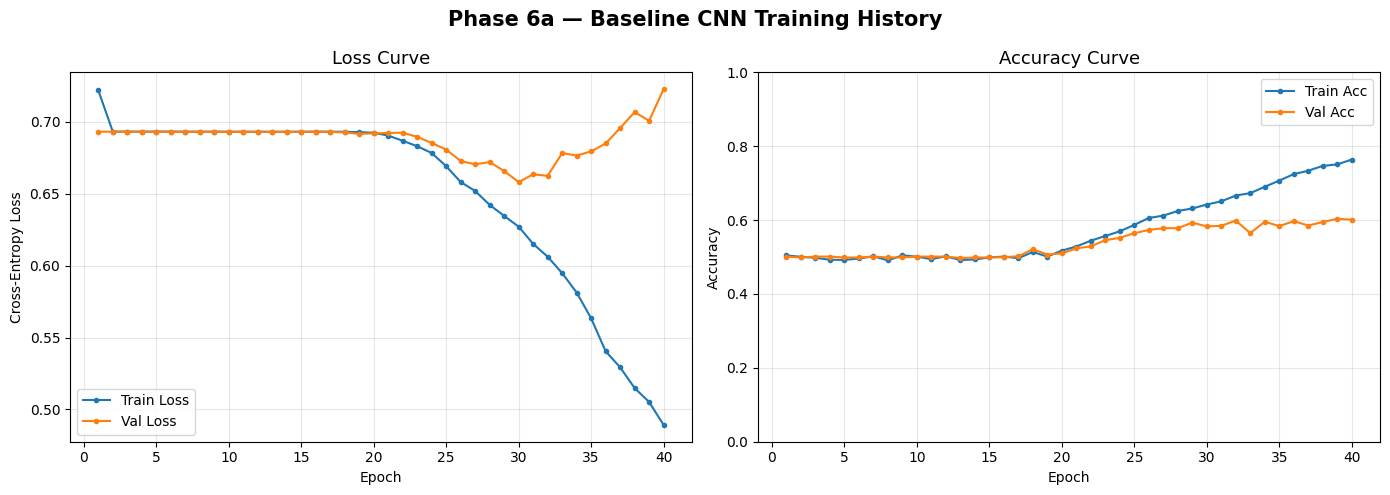

Saved: baseline_cnn_phase6a_training_curves.png ✓


In [ ]:
epochs_ran = range(1, len(history.history['loss']) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Loss
axes[0].plot(epochs_ran, history.history['loss'],     label='Train Loss', marker='o', ms=3)
axes[0].plot(epochs_ran, history.history['val_loss'], label='Val Loss',   marker='o', ms=3)
axes[0].set_title('Loss Curve', fontsize=13)
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Cross-Entropy Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Accuracy
axes[1].plot(epochs_ran, history.history['accuracy'],     label='Train Acc', marker='o', ms=3)
axes[1].plot(epochs_ran, history.history['val_accuracy'], label='Val Acc',   marker='o', ms=3)
axes[1].set_title('Accuracy Curve', fontsize=13)
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].set_ylim([0, 1])
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('Phase 6a — Baseline CNN Training History', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/baseline_cnn_phase6a_training_curves.png', dpi=150)
plt.show()
print('Saved: baseline_cnn_phase6a_training_curves.png ✓')

## Cell 12 — Test Set Evaluation

In [ ]:
# Load best weights (already restored by EarlyStopping, but explicit is safer)
model = keras.models.load_model(BEST_MODEL_PATH)

all_preds  = []
all_labels = []
all_probs  = []

for imgs, one_hot_labels in test_ds:
    probs = model(imgs, training=False).numpy()
    preds = np.argmax(probs, axis=1)
    true  = np.argmax(one_hot_labels.numpy(), axis=1)

    all_probs.extend(probs[:, 1])
    all_preds.extend(preds)
    all_labels.extend(true)

all_preds  = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs  = np.array(all_probs)

auc = roc_auc_score(all_labels, all_probs)

print('=' * 60)
print('   TEST SET EVALUATION — Baseline CNN Phase 6a')
print('=' * 60)
print(classification_report(all_labels, all_preds,
                             target_names=['Real (0)', 'Fake (1)']))
print(f'AUC-ROC : {auc:.4f}')
print('=' * 60)

   TEST SET EVALUATION — Baseline CNN Phase 6a
              precision    recall  f1-score   support

    Real (0)       0.68      0.61      0.64       644
    Fake (1)       0.49      0.56      0.52       420

    accuracy                           0.59      1064
   macro avg       0.58      0.59      0.58      1064
weighted avg       0.60      0.59      0.60      1064

AUC-ROC : 0.6201


## Cell 13 — Confusion Matrix & ROC Curve

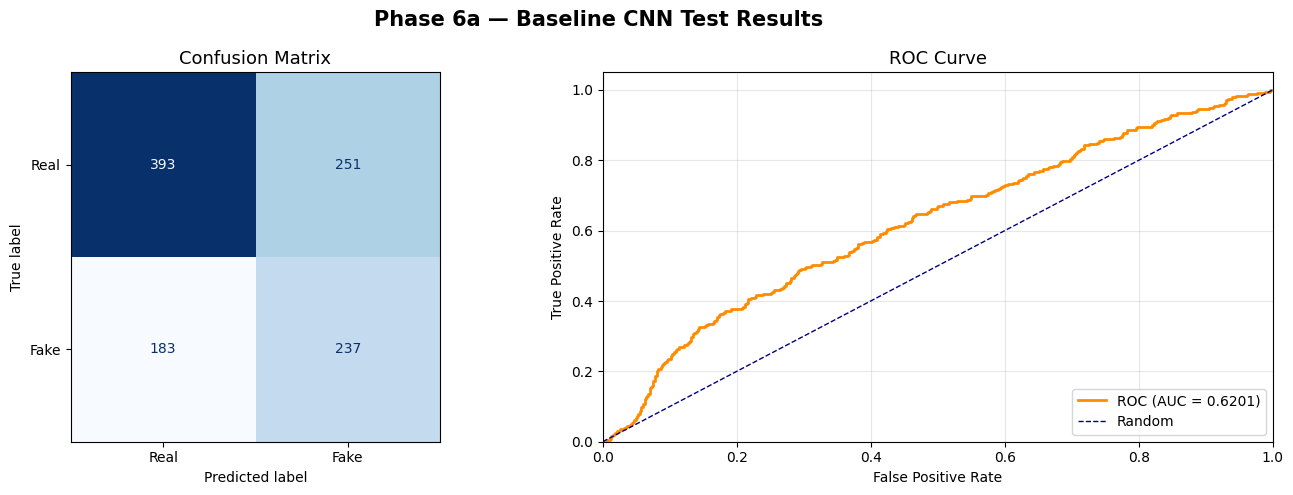

Saved: baseline_cnn_phase6a_test_results.png ✓


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm   = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                               display_labels=['Real', 'Fake'])
disp.plot(ax=axes[0], colorbar=False, cmap='Blues')
axes[0].set_title('Confusion Matrix', fontsize=13)

fpr, tpr, _ = roc_curve(all_labels, all_probs)
axes[1].plot(fpr, tpr, color='darkorange', lw=2,
             label=f'ROC (AUC = {auc:.4f})')
axes[1].plot([0, 1], [0, 1], color='navy', lw=1, linestyle='--', label='Random')
axes[1].set_xlim([0.0, 1.0])
axes[1].set_ylim([0.0, 1.05])
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curve', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, alpha=0.3)

plt.suptitle('Phase 6a — Baseline CNN Test Results', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.savefig('/content/drive/MyDrive/baseline_cnn_phase6a_test_results.png', dpi=150)
plt.show()
print('Saved: baseline_cnn_phase6a_test_results.png ✓')

## Cell 14 — Per-Category Breakdown

In [ ]:
all_dirs = FF_REAL_DIRS + FF_FAKE_DIRS + [CELEB_REAL_DIR, CELEB_FAKE_DIR]
category_results = {d: {'correct': 0, 'total': 0} for d in all_dirs}

for filepath, true_label in test_list:
    folder_name = os.path.basename(os.path.dirname(filepath))

    img = cv2.imread(filepath)
    if img is None:
        continue
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB).astype(np.float32) / 255.0
    img = cv2.resize(img, IMG_SIZE)
    img_tensor = np.expand_dims(img, axis=0)

    prob = model(img_tensor, training=False).numpy()
    pred = int(np.argmax(prob, axis=1)[0])

    if folder_name in category_results:
        category_results[folder_name]['total']   += 1
        category_results[folder_name]['correct'] += int(pred == true_label)

print('Per-category accuracy on test set:')
print(f'{"Category":<22} {"Correct":>8} {"Total":>8} {"Accuracy":>10}  Label')
print('-' * 65)
for cat, res in category_results.items():
    if res['total'] == 0:
        continue
    acc = res['correct'] / res['total']
    tag = '(real)' if cat in FF_REAL_DIRS + [CELEB_REAL_DIR] else '(fake)'
    bar = '█' * int(acc * 20)
    print(f'{cat:<22} {res["correct"]:>8} {res["total"]:>8} {acc:>10.4f}  {tag}  {bar}')

Per-category accuracy on test set:
Category                Correct    Total   Accuracy  Label
-----------------------------------------------------------------
original                    231      371     0.6226  (real)  ████████████
FaceSwap                     26       45     0.5778  (fake)  ███████████
NeuralTextures               21       44     0.4773  (fake)  █████████
FaceShifter                  49       71     0.6901  (fake)  █████████████
real                        162      273     0.5934  (real)  ███████████
fake                        141      260     0.5423  (fake)  ██████████


## Cell 15 — Save Summary

In [ ]:
summary = {
    'phase'              : 'Phase 6a — Baseline CNN',
    'purpose'            : 'From-scratch baseline to validate XceptionNet superiority empirically',
    'architecture'       : [
        'Input (224, 224, 3)',
        'Conv2D(32, 3x3) + ReLU + MaxPool(2x2)',
        'Conv2D(64, 3x3) + ReLU + MaxPool(2x2)',
        'Conv2D(128, 3x3) + ReLU + MaxPool(2x2)',
        'Flatten',
        'Dense(256) + Dropout(0.5)',
        'Dense(2, softmax)'
    ],
    'pretrained_weights' : False,
    'datasets'           : ['FF_Plus', 'CelebDF_v2'],
    'total_samples'      : len(train_list) + len(val_list) + len(test_list),
    'n_real'             : sum(1 for _, l in train_list + val_list + test_list if l == 0),
    'n_fake'             : sum(1 for _, l in train_list + val_list + test_list if l == 1),
    'train_size'         : len(train_list),
    'val_size'           : len(val_list),
    'test_size'          : len(test_list),
    'accuracy'           : float(accuracy_score(all_labels, all_preds)),
    'f1_fake'            : float(f1_score(all_labels, all_preds, pos_label=1)),
    'f1_real'            : float(f1_score(all_labels, all_preds, pos_label=0)),
    'f1_macro'           : float(f1_score(all_labels, all_preds, average='macro')),
    'auc_roc'            : float(auc),
    'best_val_loss'      : float(best_val_loss),
    'best_val_acc'       : float(best_val_acc),
    'epochs_run'         : len(history.history['loss']),
    'learning_rate'      : LEARNING_RATE,
    'optimizer'          : 'Adam',
    'loss'               : 'categorical_crossentropy',
    'dropout'            : 0.5,
    'seed'               : SEED,
    'early_stop_patience': EARLY_STOP_PATIENCE,
}

summary_path = '/content/drive/MyDrive/baseline_cnn_phase6a_results_summary.json'
with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print('Summary saved to Drive ✓')
print(json.dumps(summary, indent=2))

Summary saved to Drive ✓
{
  "phase": "Phase 6a \u2014 Baseline CNN",
  "purpose": "From-scratch baseline to validate XceptionNet superiority empirically",
  "architecture": [
    "Input (224, 224, 3)",
    "Conv2D(32, 3x3) + ReLU + MaxPool(2x2)",
    "Conv2D(64, 3x3) + ReLU + MaxPool(2x2)",
    "Conv2D(128, 3x3) + ReLU + MaxPool(2x2)",
    "Flatten",
    "Dense(256) + Dropout(0.5)",
    "Dense(2, softmax)"
  ],
  "pretrained_weights": false,
  "datasets": [
    "FF_Plus",
    "CelebDF_v2"
  ],
  "total_samples": 22183,
  "n_real": 11535,
  "n_fake": 10648,
  "train_size": 19858,
  "val_size": 1261,
  "test_size": 1064,
  "accuracy": 0.5921052631578947,
  "f1_fake": 0.5220264317180616,
  "f1_real": 0.6442622950819672,
  "f1_macro": 0.5831443634000144,
  "auc_roc": 0.6201456669624372,
  "best_val_loss": 0.6580989360809326,
  "best_val_acc": 0.6034892797470093,
  "epochs_run": 40,
  "learning_rate": 0.001,
  "optimizer": "Adam",
  "loss": "categorical_crossentropy",
  "dropout": 0.5,
  "

In [ ]:
# -*- coding: utf-8 -*-
"""
XceptionNet Training Pipeline for Deepfake Detection on PPG Maps
================================================================
Datasets : FaceForensics++ (C23) + Celeb-DF v2
Input    : 3-channel PPG maps (224×224 PNG) from preprocessing.py
Model    : XceptionNet (pretrained ImageNet via timm)
Target   : Binary classification — real (0) vs fake (1)

Anti-overfitting stack:
  - Heavy Albumentations augmentation (train only)
  - Label smoothing loss
  - CosineAnnealingWarmRestarts LR schedule
  - MixUp / CutMix
  - Dropout in classifier head
  - Early stopping + best-model checkpointing
  - Gradient clipping
  - WeightedRandomSampler for class imbalance

GPU OPTIMIZATIONS (RTX 40/50 series):
  - torch.compile() for graph optimization
  - tf32 matmul + cudnn benchmark enabled
  - autocast with bfloat16 (Ada Lovelace / Blackwell native)
  - Non-blocking CUDA transfers
  - persistent_workers=True in DataLoader
  - NUM_WORKERS=0 on Windows to avoid multiprocessing issues
"""
import ssl
ssl._create_default_https_context = ssl._create_unverified_context

import os
import sys
import csv
import time
import random
import warnings
import numpy as np
import pandas as pd
import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from collections import defaultdict, Counter
from tqdm import tqdm

import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader, WeightedRandomSampler
from torch.amp import GradScaler, autocast          # updated API (torch >= 2.1)
from torch.utils.tensorboard import SummaryWriter

import timm
import albumentations as A
from albumentations.pytorch import ToTensorV2
from PIL import Image

from sklearn.metrics import (
    accuracy_score, f1_score, roc_auc_score, confusion_matrix,
    classification_report, roc_curve, precision_recall_curve,
    average_precision_score
)

warnings.filterwarnings('ignore')

# ─────────────────────────────────────────────────────────────────────────────
# GPU BACKEND SETUP  (must happen before any CUDA calls)
# ─────────────────────────────────────────────────────────────────────────────
torch.backends.cuda.matmul.allow_tf32 = True   # free throughput on Ampere+
torch.backends.cudnn.allow_tf32       = True
torch.backends.cudnn.benchmark        = True   # auto-tune kernels

# ─────────────────────────────────────────────────────────────────────────────
# CONFIGURATION
# ─────────────────────────────────────────────────────────────────────────────
DESKTOP      = os.path.join(os.path.expanduser('~'), 'Desktop')
PPG_ROOT     = '/content/PPG_MAPS' # Changed from os.path.join(DESKTOP, 'PPG_MAPS')
OUTPUT_DIR   = os.path.join(DESKTOP, 'XceptionNet_Results')

# Training hyperparameters
IMG_SIZE      = 224
BATCH_SIZE    = 32           # Safe for RTX 40/50 with 12GB+ VRAM
ACCUM_STEPS   = 1            # Gradient accumulation (increase if OOM)
NUM_EPOCHS    = 60
BASE_LR       = 3e-4
WEIGHT_DECAY  = 1e-4
LABEL_SMOOTH  = 0.1
PATIENCE      = 12
MIN_DELTA     = 1e-4
GRAD_CLIP     = 1.0
WARMUP_EPOCHS = 3
# Windows: NUM_WORKERS > 0 causes multiprocessing issues with PyTorch DataLoader
NUM_WORKERS   = 0
PIN_MEMORY    = True
MIXUP_ALPHA   = 0.4
CUTMIX_PROB   = 0.5
DROPOUT_RATE  = 0.4
SEED          = 42

# AMP dtype — bfloat16 is natively supported on RTX 40/50 (Ada/Blackwell)
AMP_DTYPE     = torch.bfloat16

# Label mapping
REAL_CATEGORIES = {'original', 'real'}

# Device — GPU only, hard-fail if not available
if not torch.cuda.is_available():
    raise EnvironmentError(
        "CUDA GPU not found. This script requires an NVIDIA GPU.\n"
        "Check your PyTorch install: pip install torch --index-url https://download.pytorch.org/whl/cu121"
    )
DEVICE = torch.device('cuda')


# ─────────────────────────────────────────────────────────────────────────────
# REPRODUCIBILITY
# ─────────────────────────────────────────────────────────────────────────────
def set_seed(seed: int = SEED):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    # NOTE: deterministic mode is intentionally OFF for max GPU speed
    torch.backends.cudnn.deterministic = False


# ─────────────────────────────────────────────────────────────────────────────
# DATASET
# ─────────────────────────────────────────────────────────────────────────────
def discover_maps(ppg_root: str, split: str) -> list[dict]:
    records = []
    for dataset in ['FF_Plus', 'CelebDF_v2']:
        split_dir = os.path.join(ppg_root, dataset, 'THREE_CHANNEL', split)
        if not os.path.exists(split_dir):
            continue
        for cat in os.listdir(split_dir):
            cat_dir = os.path.join(split_dir, cat)
            if not os.path.isdir(cat_dir):
                continue
            label = 0 if cat in REAL_CATEGORIES else 1
            for fname in os.listdir(cat_dir):
                if fname.endswith('.png'):
                    records.append({
                        'path'    : os.path.join(cat_dir, fname),
                        'label'   : label,
                        'dataset' : dataset,
                        'category': cat,
                        'split'   : split,
                    })
    return records


def get_train_transform() -> A.Compose:
    return A.Compose([
        A.RandomResizedCrop(size=(IMG_SIZE, IMG_SIZE), scale=(0.75, 1.0), ratio=(0.9, 1.1)),
        A.HorizontalFlip(p=0.5),
        A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.1, rotate_limit=10, p=0.4),
        A.OneOf([
            A.GaussNoise(var_limit=(5, 25), p=1.0),
            A.GaussianBlur(blur_limit=(3, 5), p=1.0),
            A.MotionBlur(blur_limit=5, p=1.0),
        ], p=0.4),
        A.OneOf([
            A.RandomBrightnessContrast(brightness_limit=0.15, contrast_limit=0.15, p=1.0),
            A.HueSaturationValue(hue_shift_limit=10, sat_shift_limit=20, val_shift_limit=10, p=1.0),
            A.CLAHE(clip_limit=2.0, p=1.0),
        ], p=0.4),
        A.CoarseDropout(max_holes=8, max_height=24, max_width=24,
                        min_holes=1, fill_value=0, p=0.3),
        A.GridDistortion(num_steps=5, distort_limit=0.1, p=0.2),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


def get_val_transform() -> A.Compose:
    return A.Compose([
        A.Resize(height=IMG_SIZE, width=IMG_SIZE),
        A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
        ToTensorV2(),
    ])


class PPGMapDataset(Dataset):
    def __init__(self, records: list[dict], transform: A.Compose):
        self.records   = records
        self.transform = transform

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx: int):
        rec = self.records[idx]
        img = np.array(Image.open(rec['path']).convert('RGB'), dtype=np.uint8)
        if self.transform:
            img = self.transform(image=img)['image']
        return img, torch.tensor(rec['label'], dtype=torch.long)


# ─────────────────────────────────────────────────────────────────────────────
# MODEL
# ─────────────────────────────────────────────────────────────────────────────
class XceptionDetector(nn.Module):
    def __init__(self, num_classes: int = 2, dropout: float = DROPOUT_RATE,
                 pretrained: bool = True):
        super().__init__()
        self.backbone = timm.create_model(
            'xception',
            pretrained=pretrained,
            num_classes=0,
            global_pool='avg',
        )
        feat_dim = self.backbone.num_features   # 2048

        self.head = nn.Sequential(
            nn.LayerNorm(feat_dim),
            nn.Dropout(dropout),
            nn.Linear(feat_dim, 512),
            nn.GELU(),
            nn.Dropout(dropout * 0.5),
            nn.Linear(512, num_classes),
        )

        for m in self.head.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_uniform_(m.weight)
                nn.init.zeros_(m.bias)

    def forward(self, x: torch.Tensor) -> torch.Tensor:
        feat = self.backbone(x)
        return self.head(feat)

    def unfreeze_all(self):
        for p in self.parameters():
            p.requires_grad = True


# ─────────────────────────────────────────────────────────────────────────────
# LOSS — Label Smoothing Cross-Entropy
# ─────────────────────────────────────────────────────────────────────────────
class LabelSmoothingCE(nn.Module):
    def __init__(self, smoothing: float = LABEL_SMOOTH, num_classes: int = 2):
        super().__init__()
        self.smoothing   = smoothing
        self.num_classes = num_classes

    def forward(self, logits: torch.Tensor, targets: torch.Tensor) -> torch.Tensor:
        log_probs = F.log_softmax(logits, dim=-1)
        with torch.no_grad():
            smooth_targets = torch.full_like(log_probs, self.smoothing / (self.num_classes - 1))
            smooth_targets.scatter_(1, targets.unsqueeze(1), 1.0 - self.smoothing)
        return -(smooth_targets * log_probs).sum(dim=-1).mean()


# ─────────────────────────────────────────────────────────────────────────────
# MIXUP / CUTMIX
# ─────────────────────────────────────────────────────────────────────────────
def mixup_data(x, y, alpha=MIXUP_ALPHA):
    lam = np.random.beta(alpha, alpha) if alpha > 0 else 1.0
    idx = torch.randperm(x.size(0), device=x.device)
    x_mix = lam * x + (1 - lam) * x[idx]
    return x_mix, y, y[idx], lam


def cutmix_data(x, y, alpha=1.0):
    lam  = np.random.beta(alpha, alpha)
    idx  = torch.randperm(x.size(0), device=x.device)
    _, _, H, W = x.size()
    cut_ratio = np.sqrt(1 - lam)
    cut_h, cut_w = int(H * cut_ratio), int(W * cut_ratio)
    cx, cy = np.random.randint(W), np.random.randint(H)
    x1 = np.clip(cx - cut_w // 2, 0, W)
    x2 = np.clip(cx + cut_w // 2, 0, W)
    y1 = np.clip(cy - cut_h // 2, 0, H)
    y2 = np.clip(cy + cut_h // 2, 0, H)
    x_mix = x.clone()
    x_mix[:, :, y1:y2, x1:x2] = x[idx, :, y1:y2, x1:x2]
    lam = 1 - (x2 - x1) * (y2 - y1) / (W * H)
    return x_mix, y, y[idx], lam


def mixed_loss(criterion, logits, y_a, y_b, lam):
    return lam * criterion(logits, y_a) + (1 - lam) * criterion(logits, y_b)


# ─────────────────────────────────────────────────────────────────────────────
# WEIGHTED SAMPLER
# ─────────────────────────────────────────────────────────────────────────────
def make_weighted_sampler(records: list[dict]) -> WeightedRandomSampler:
    labels  = [r['label'] for r in records]
    counts  = Counter(labels)
    weights = {lbl: 1.0 / cnt for lbl, cnt in counts.items()}
    sample_weights = [weights[lbl] for lbl in labels]
    return WeightedRandomSampler(
        weights=torch.DoubleTensor(sample_weights),
        num_samples=len(sample_weights),
        replacement=True,
    )


# ─────────────────────────────────────────────────────────────────────────────
# METRICS
# ─────────────────────────────────────────────────────────────────────────────
def compute_metrics(y_true, y_pred, y_prob) -> dict:
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred, labels=[0, 1]).ravel()
    sensitivity = tp / (tp + fn + 1e-8)
    specificity = tn / (tn + fp + 1e-8)
    return {
        'accuracy'   : accuracy_score(y_true, y_pred),
        'f1'         : f1_score(y_true, y_pred, average='binary'),
        'f1_macro'   : f1_score(y_true, y_pred, average='macro'),
        'auroc'      : roc_auc_score(y_true, y_prob),
        'ap'         : average_precision_score(y_true, y_prob),
        'sensitivity': sensitivity,
        'specificity': specificity,
        'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn),
    }


# ─────────────────────────────────────────────────────────────────────────────
# EARLY STOPPING
# ─────────────────────────────────────────────────────────────────────────────
class EarlyStopping:
    def __init__(self, patience: int = PATIENCE, min_delta: float = MIN_DELTA,
                 mode: str = 'max'):
        self.patience    = patience
        self.min_delta   = min_delta
        self.mode        = mode
        self.best        = -np.inf if mode == 'max' else np.inf
        self.counter     = 0
        self.should_stop = False

    def step(self, value: float) -> bool:
        improved = (value > self.best + self.min_delta) if self.mode == 'max' \
                   else (value < self.best - self.min_delta)
        if improved:
            self.best    = value
            self.counter = 0
        else:
            self.counter += 1
            if self.counter >= self.patience:
                self.should_stop = True
        return improved


# ─────────────────────────────────────────────────────────────────────────────
# TRAIN / VALIDATE LOOPS
# ─────────────────────────────────────────────────────────────────────────────
def train_one_epoch(model, loader, optimizer, criterion, scaler,
                    use_mixup: bool = True, use_cutmix: bool = True) -> dict:
    model.train()
    total_loss, all_preds, all_labels = 0.0, [], []

    optimizer.zero_grad(set_to_none=True)

    for step, (imgs, labels) in enumerate(tqdm(loader, desc='  train', leave=False)):
        # Non-blocking GPU transfer
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        # MixUp / CutMix
        use_aug = use_mixup or use_cutmix
        if use_aug and random.random() < 0.5:
            if use_cutmix and random.random() < CUTMIX_PROB:
                imgs, y_a, y_b, lam = cutmix_data(imgs, labels)
            else:
                imgs, y_a, y_b, lam = mixup_data(imgs, labels)
            with autocast(device_type='cuda', dtype=AMP_DTYPE):
                logits = model(imgs)
                loss   = mixed_loss(criterion, logits, y_a, y_b, lam)
        else:
            with autocast(device_type='cuda', dtype=AMP_DTYPE):
                logits = model(imgs)
                loss   = criterion(logits, labels)

        # Gradient accumulation
        loss = loss / ACCUM_STEPS
        scaler.scale(loss).backward()

        if (step + 1) % ACCUM_STEPS == 0 or (step + 1) == len(loader):
            scaler.unscale_(optimizer)
            nn.utils.clip_grad_norm_(model.parameters(), GRAD_CLIP)
            scaler.step(optimizer)
            scaler.update()
            optimizer.zero_grad(set_to_none=True)

        total_loss += loss.item() * ACCUM_STEPS
        preds = logits.argmax(dim=1).detach().cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    n = len(loader)
    return {
        'loss'    : total_loss / n,
        'accuracy': accuracy_score(all_labels, all_preds),
        'f1'      : f1_score(all_labels, all_preds, average='binary', zero_division=0),
    }


@torch.no_grad()
def validate(model, loader, criterion) -> dict:
    model.eval()
    total_loss, all_preds, all_labels, all_probs = 0.0, [], [], []

    for imgs, labels in tqdm(loader, desc='  val  ', leave=False):
        imgs   = imgs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)
        with autocast(device_type='cuda', dtype=AMP_DTYPE):
            logits = model(imgs)
            loss   = criterion(logits, labels)
        total_loss += loss.item()
        probs  = F.softmax(logits, dim=1)[:, 1].float().cpu().numpy()
        preds  = logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.cpu().numpy())

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    metrics['loss'] = total_loss / len(loader)
    return metrics


# ─────────────────────────────────────────────────────────────────────────────
# PLOTTING
# ─────────────────────────────────────────────────────────────────────────────
def plot_training_curves(history: dict, save_dir: str):
    fig, axes = plt.subplots(2, 2, figsize=(14, 10))
    epochs = range(1, len(history['train_loss']) + 1)

    def ax_plot(ax, train, val, ylabel, title):
        ax.plot(epochs, train, 'b-o', markersize=3, label='Train')
        ax.plot(epochs, val,   'r-o', markersize=3, label='Val')
        ax.set_xlabel('Epoch'); ax.set_ylabel(ylabel); ax.set_title(title)
        ax.legend(); ax.grid(alpha=0.3)

    ax_plot(axes[0,0], history['train_loss'], history['val_loss'],   'Loss',     'Train vs Val Loss')
    ax_plot(axes[0,1], history['train_acc'],  history['val_acc'],    'Accuracy', 'Train vs Val Accuracy')
    ax_plot(axes[1,0], history['train_f1'],   history['val_f1'],     'F1',       'Train vs Val F1')
    axes[1,1].plot(epochs, history['val_auroc'], 'g-o', markersize=3)
    axes[1,1].set_xlabel('Epoch'); axes[1,1].set_ylabel('AUROC')
    axes[1,1].set_title('Validation AUROC'); axes[1,1].grid(alpha=0.3)

    plt.suptitle('XceptionNet Training Curves', fontsize=14)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'training_curves.png'), dpi=120)
    plt.close()


def plot_confusion_matrix(cm, save_dir: str, title: str = 'Confusion Matrix'):
    fig, ax = plt.subplots(figsize=(6, 5))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax,
                xticklabels=['Real', 'Fake'],
                yticklabels=['Real', 'Fake'])
    ax.set_xlabel('Predicted'); ax.set_ylabel('True')
    ax.set_title(title)
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, f'{title.lower().replace(" ", "_")}.png'), dpi=120)
    plt.close()


def plot_roc_pr(y_true, y_prob, save_dir: str):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

    fpr, tpr, _ = roc_curve(y_true, y_prob)
    auc          = roc_auc_score(y_true, y_prob)
    ax1.plot(fpr, tpr, 'b-', lw=2, label=f'AUC = {auc:.4f}')
    ax1.plot([0,1],[0,1],'k--'); ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR')
    ax1.set_title('ROC Curve'); ax1.legend(); ax1.grid(alpha=0.3)

    prec, rec, _ = precision_recall_curve(y_true, y_prob)
    ap            = average_precision_score(y_true, y_prob)
    ax2.plot(rec, prec, 'r-', lw=2, label=f'AP = {ap:.4f}')
    ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
    ax2.set_title('Precision-Recall Curve'); ax2.legend(); ax2.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'roc_pr_curves.png'), dpi=120)
    plt.close()


# ─────────────────────────────────────────────────────────────────────────────
# TEST EVALUATION
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_test(model, loader) -> tuple[dict, list, list, list]:
    model.eval()
    all_preds, all_labels, all_probs = [], [], []

    for imgs, labels in tqdm(loader, desc='  test '):
        imgs = imgs.to(DEVICE, non_blocking=True)
        with autocast(device_type='cuda', dtype=AMP_DTYPE):
            logits = model(imgs)
        probs = F.softmax(logits, dim=1)[:, 1].float().cpu().numpy()
        preds = logits.argmax(dim=1).cpu().numpy()
        all_probs.extend(probs)
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())

    metrics = compute_metrics(all_labels, all_preds, all_probs)
    return metrics, all_labels, all_preds, all_probs


# ─────────────────────────────────────────────────────────────────────────────
# PER-CATEGORY TEST BREAKDOWN
# ─────────────────────────────────────────────────────────────────────────────
@torch.no_grad()
def evaluate_per_category(model, ppg_root: str, save_dir: str):
    model.eval()
    results = []

    for dataset in ['FF_Plus', 'CelebDF_v2']:
        split_dir = os.path.join(ppg_root, dataset, 'THREE_CHANNEL', 'test')
        if not os.path.exists(split_dir):
            continue
        for cat in os.listdir(split_dir):
            cat_dir = os.path.join(split_dir, cat)
            if not os.path.isdir(cat_dir):
                continue
            recs = [{'path': os.path.join(cat_dir, f),
                     'label': 0 if cat in REAL_CATEGORIES else 1}
                    for f in os.listdir(cat_dir) if f.endswith('.png')]
            if not recs:
                continue
            ds  = PPGMapDataset(recs, get_val_transform())
            ldr = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                             num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
            preds_all, probs_all, labels_all = [], [], []
            for imgs, labels in ldr:
                imgs = imgs.to(DEVICE, non_blocking=True)
                with autocast(device_type='cuda', dtype=AMP_DTYPE):
                    logits = model(imgs)
                probs_all.extend(F.softmax(logits, dim=1)[:, 1].float().cpu().numpy())
                preds_all.extend(logits.argmax(1).cpu().numpy())
                labels_all.extend(labels.numpy())

            acc = accuracy_score(labels_all, preds_all)
            auc = roc_auc_score(labels_all, probs_all) if len(set(labels_all)) > 1 else float('nan')
            f1  = f1_score(labels_all, preds_all, average='binary', zero_division=0)
            results.append({'dataset': dataset, 'category': cat,
                            'n_maps': len(recs), 'accuracy': acc, 'f1': f1, 'auroc': auc})

    df = pd.DataFrame(results).sort_values(['dataset', 'category'])
    csv_path = os.path.join(save_dir, 'per_category_metrics.csv')
    df.to_csv(csv_path, index=False)
    print('\nPer-Category Test Metrics:')
    print(df.to_string(index=False))
    print(f'\nSaved → {csv_path}')

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    for ax, col in zip(axes, ['accuracy', 'f1', 'auroc']):
        vals   = df[col].values
        cats   = [f"{r['dataset']}/{r['category']}" for _, r in df.iterrows()]
        colors = ['#2196F3' if 'real' in c.lower() or 'original' in c.lower()
                  else '#F44336' for c in cats]
        ax.barh(cats, vals, color=colors)
        ax.set_xlim(0, 1); ax.set_xlabel(col.upper()); ax.grid(axis='x', alpha=0.3)
        ax.set_title(f'Per-Category {col.upper()}')
    plt.tight_layout()
    plt.savefig(os.path.join(save_dir, 'per_category_breakdown.png'), dpi=120)
    plt.close()
    return df


# ─────────────────────────────────────────────────────────────────────────────
# MAIN TRAINING LOOP
# ─────────────────────────────────────────────────────────────────────────────
def main():
    set_seed()

    print('=' * 70)
    print('XceptionNet — Deepfake Detection on PPG Maps')
    print('=' * 70)
    print(f'Device       : {DEVICE}')
    print(f'GPU          : {torch.cuda.get_device_name(0)}')
    print(f'VRAM         : {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
    print(f'AMP dtype    : {AMP_DTYPE}')
    print(f'Batch size   : {BATCH_SIZE}  (accum steps: {ACCUM_STEPS})')
    print(f'Effective bs : {BATCH_SIZE * ACCUM_STEPS}')
    print(f'PPG root     : {PPG_ROOT}')
    print(f'Output dir   : {OUTPUT_DIR}')
    print()

    os.makedirs(OUTPUT_DIR, exist_ok=True)

    # ── Discover data ──────────────────────────────────────────────────────────
    print('Discovering PPG maps...')
    train_recs = discover_maps(PPG_ROOT, 'train')
    val_recs   = discover_maps(PPG_ROOT, 'val')
    test_recs  = discover_maps(PPG_ROOT, 'test')

    if not train_recs:
        raise RuntimeError(
            f'No training maps found under {PPG_ROOT}.\n'
            'Run preprocessing.py first to generate PPG_MAPS.'
        )

    train_labels = Counter(r['label'] for r in train_recs)
    val_labels   = Counter(r['label'] for r in val_recs)
    test_labels  = Counter(r['label'] for r in test_recs)

    print(f'Train: {len(train_recs):,} maps  (real={train_labels[0]:,}, fake={train_labels[1]:,})')
    print(f'Val  : {len(val_recs):,} maps  (real={val_labels[0]:,}, fake={val_labels[1]:,})')
    print(f'Test : {len(test_recs):,} maps  (real={test_labels[0]:,}, fake={test_labels[1]:,})')
    print()

    # ── Datasets & DataLoaders ─────────────────────────────────────────────────
    train_ds = PPGMapDataset(train_recs, get_train_transform())
    val_ds   = PPGMapDataset(val_recs,   get_val_transform())
    test_ds  = PPGMapDataset(test_recs,  get_val_transform())

    train_sampler = make_weighted_sampler(train_recs)

    # NUM_WORKERS=0 on Windows avoids multiprocessing spawn issues
    train_loader = DataLoader(
        train_ds, batch_size=BATCH_SIZE, sampler=train_sampler,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY, drop_last=True,
        persistent_workers=False,   # must be False when NUM_WORKERS=0
    )
    val_loader = DataLoader(
        val_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=False,
    )
    test_loader = DataLoader(
        test_ds, batch_size=BATCH_SIZE, shuffle=False,
        num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY,
        persistent_workers=False,
    )

    # ── Model ──────────────────────────────────────────────────────────────────
    print('Building XceptionNet model...')
    model = XceptionDetector(num_classes=2, dropout=DROPOUT_RATE, pretrained=True).to(DEVICE)

    # torch.compile requires Triton which is NOT available on Windows — skip it
    print('torch.compile() skipped (Triton not supported on Windows)')

    total_params     = sum(p.numel() for p in model.parameters())
    trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
    print(f'Total params    : {total_params:,}')
    print(f'Trainable params: {trainable_params:,}')
    print()

    # ── Loss, Optimizer, Scheduler ────────────────────────────────────────────
    criterion = LabelSmoothingCE(smoothing=LABEL_SMOOTH, num_classes=2)

    optimizer = optim.AdamW(
        [
            {'params': model.backbone.parameters(), 'lr': BASE_LR * 0.1},
            {'params': model.head.parameters(),     'lr': BASE_LR},
        ],
        weight_decay=WEIGHT_DECAY,
        fused=True,    # fused AdamW kernel — faster on CUDA
    )

    scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
        optimizer, T_0=20, T_mult=2, eta_min=1e-6
    )

    # GradScaler — use 'cuda' device string (updated API)
    scaler  = GradScaler(device='cuda')
    stopper = EarlyStopping(patience=PATIENCE, mode='max')
    writer  = SummaryWriter(log_dir=os.path.join(OUTPUT_DIR, 'tensorboard'))

    # ── Training ──────────────────────────────────────────────────────────────
    history   = defaultdict(list)
    best_ckpt = os.path.join(OUTPUT_DIR, 'best_model.pth')
    best_auroc = 0.0

    print(f'Starting training for {NUM_EPOCHS} epochs...')
    print('TensorBoard: tensorboard --logdir', os.path.join(OUTPUT_DIR, 'tensorboard'))
    print()

    for epoch in range(1, NUM_EPOCHS + 1):
        t0 = time.time()

        if epoch == WARMUP_EPOCHS + 1:
            model.unfreeze_all()
            print(f'  [Epoch {epoch}] All params unfrozen')

        # Clear CUDA cache before each epoch to keep VRAM clean
        torch.cuda.empty_cache()

        train_m = train_one_epoch(model, train_loader, optimizer, criterion, scaler)
        val_m   = validate(model, val_loader, criterion)
        scheduler.step(epoch)

        elapsed = time.time() - t0
        lr_now  = optimizer.param_groups[0]['lr']

        # GPU memory info
        vram_used = torch.cuda.memory_allocated() / 1e9
        vram_peak = torch.cuda.max_memory_allocated() / 1e9

        print(f'Epoch [{epoch:03d}/{NUM_EPOCHS}] '
              f'| Loss: {train_m["loss"]:.4f}/{val_m["loss"]:.4f} '
              f'| Acc: {train_m["accuracy"]:.4f}/{val_m["accuracy"]:.4f} '
              f'| F1: {train_m["f1"]:.4f}/{val_m["f1"]:.4f} '
              f'| AUROC: {val_m["auroc"]:.4f} '
              f'| LR: {lr_now:.2e} '
              f'| VRAM: {vram_used:.1f}/{vram_peak:.1f}GB '
              f'| {elapsed:.1f}s')

        torch.cuda.reset_peak_memory_stats()

        # History
        history['train_loss'].append(train_m['loss'])
        history['val_loss'].append(val_m['loss'])
        history['train_acc'].append(train_m['accuracy'])
        history['val_acc'].append(val_m['accuracy'])
        history['train_f1'].append(train_m['f1'])
        history['val_f1'].append(val_m['f1'])
        history['val_auroc'].append(val_m['auroc'])

        # TensorBoard
        for k, v in train_m.items():
            writer.add_scalar(f'train/{k}', v, epoch)
        for k, v in val_m.items():
            writer.add_scalar(f'val/{k}', v, epoch)
        writer.add_scalar('lr', lr_now, epoch)
        writer.add_scalar('vram_gb', vram_used, epoch)

        # Checkpoint
        improved = stopper.step(val_m['auroc'])
        if improved:
            best_auroc = val_m['auroc']
            torch.save({
                'epoch'     : epoch,
                'state_dict': model.state_dict(),
                'optimizer' : optimizer.state_dict(),
                'val_auroc' : best_auroc,
                'val_acc'   : val_m['accuracy'],
                'val_f1'    : val_m['f1'],
            }, best_ckpt)
            print(f'  ✓ Best model saved (AUROC={best_auroc:.4f})')

        if stopper.should_stop:
            print(f'\nEarly stopping at epoch {epoch} (no improvement for {PATIENCE} epochs)')
            break

    writer.close()

    # ── Plot training curves ───────────────────────────────────────────────────
    plot_training_curves(dict(history), OUTPUT_DIR)
    print(f'\nTraining curves → {OUTPUT_DIR}/training_curves.png')

    # ── Load best model & test ─────────────────────────────────────────────────
    print('\n' + '=' * 70)
    print('FINAL TEST EVALUATION — loading best checkpoint')
    print('=' * 70)
    ckpt = torch.load(best_ckpt, map_location=DEVICE)
    model.load_state_dict(ckpt['state_dict'])
    print(f'Best checkpoint: epoch {ckpt["epoch"]}, val AUROC={ckpt["val_auroc"]:.4f}')

    test_m, y_true, y_pred, y_prob = evaluate_test(model, test_loader)

    print('\n── Test Metrics ─────────────────────────────────────────────────────')
    print(f'  Accuracy   : {test_m["accuracy"]:.4f}')
    print(f'  F1 (binary): {test_m["f1"]:.4f}')
    print(f'  F1 (macro) : {test_m["f1_macro"]:.4f}')
    print(f'  AUROC      : {test_m["auroc"]:.4f}')
    print(f'  Avg Prec   : {test_m["ap"]:.4f}')
    print(f'  Sensitivity: {test_m["sensitivity"]:.4f}')
    print(f'  Specificity: {test_m["specificity"]:.4f}')
    print(f'  TP={test_m["tp"]}  TN={test_m["tn"]}  FP={test_m["fp"]}  FN={test_m["fn"]}')

    print('\n── Classification Report ────────────────────────────────────────────')
    print(classification_report(y_true, y_pred, target_names=['Real', 'Fake'], digits=4))

    cm = confusion_matrix(y_true, y_pred, labels=[0, 1])
    plot_confusion_matrix(cm, OUTPUT_DIR, title='Test Confusion Matrix')
    plot_roc_pr(y_true, y_prob, OUTPUT_DIR)

    print('\n── Per-Category Breakdown ───────────────────────────────────────────')
    evaluate_per_category(model, PPG_ROOT, OUTPUT_DIR)

    metrics_path = os.path.join(OUTPUT_DIR, 'test_metrics.csv')
    with open(metrics_path, 'w', newline='') as f:
        w = csv.writer(f)
        w.writerow(['metric', 'value'])
        for k, v in test_m.items():
            w.writerow([k, f'{v:.6f}' if isinstance(v, float) else v])
    print(f'\nTest metrics saved → {metrics_path}')

    print('\n' + '=' * 70)
    print(f'ALL OUTPUTS SAVED TO: {OUTPUT_DIR}')
    print('  best_model.pth')
    print('  training_curves.png')
    print('  test_confusion_matrix.png')
    print('  roc_pr_curves.png')
    print('  per_category_breakdown.png')
    print('  per_category_metrics.csv')
    print('  test_metrics.csv')
    print('  tensorboard/')
    print('=' * 70)


if __name__ == '__main__':
    main()

XceptionNet — Deepfake Detection on PPG Maps
Device       : cuda
GPU          : Tesla T4
VRAM         : 15.6 GB
AMP dtype    : torch.bfloat16
Batch size   : 32  (accum steps: 1)
Effective bs : 32
PPG root     : /content/PPG_MAPS
Output dir   : /root/Desktop/XceptionNet_Results

Discovering PPG maps...
Train: 19,858 maps  (real=10,262, fake=9,596)
Val  : 1,261 maps  (real=629, fake=632)
Test : 1,064 maps  (real=644, fake=420)

Building XceptionNet model...
Downloading: "https://github.com/rwightman/pytorch-image-models/releases/download/v0.1-cadene/xception-43020ad28.pth" to /root/.cache/torch/hub/checkpoints/xception-43020ad28.pth
torch.compile() skipped (Triton not supported on Windows)
Total params    : 21,861,162
Trainable params: 21,861,162

Starting training for 60 epochs...
TensorBoard: tensorboard --logdir /root/Desktop/XceptionNet_Results/tensorboard



Epoch [001/60] | Loss: 0.9335/0.6921 | Acc: 0.5163/0.5361 | F1: 0.5189/0.5651 | AUROC: 0.5592 | LR: 2.98e-05 | VRAM: 0.3/2.6GB | 716.8s
  ✓ Best model saved (AUROC=0.5592)


Epoch [002/60] | Loss: 0.6922/0.6731 | Acc: 0.5530/0.5995 | F1: 0.5325/0.4370 | AUROC: 0.6784 | LR: 2.93e-05 | VRAM: 0.3/2.6GB | 708.3s
  ✓ Best model saved (AUROC=0.6784)


Epoch [003/60] | Loss: 0.6825/0.6565 | Acc: 0.5609/0.6487 | F1: 0.5379/0.6701 | AUROC: 0.7009 | LR: 2.84e-05 | VRAM: 0.3/2.6GB | 702.9s
  ✓ Best model saved (AUROC=0.7009)
  [Epoch 4] All params unfrozen


Epoch [004/60] | Loss: 0.6728/0.6468 | Acc: 0.5964/0.6677 | F1: 0.5698/0.6458 | AUROC: 0.7264 | LR: 2.72e-05 | VRAM: 0.3/2.6GB | 700.3s
  ✓ Best model saved (AUROC=0.7264)


...

Epoch [010/60] | Loss: 0.6469/0.6335 | Acc: 0.6370/0.6764 | F1: 0.6168/0.7039 | AUROC: 0.7522 | LR: 1.55e-05 | VRAM: 0.3/2.6GB | 711.6s


Epoch [011/60] | Loss: 0.6439/0.6306 | Acc: 0.6479/0.6669 | F1: 0.6404/0.6749 | AUROC: 0.7486 | LR: 1.32e-05 | VRAM: 0.3/2.6GB | 708.8s


Epoch [012/60] | Loss: 0.6395/0.6295 | Acc: 0.6445/0.6852 | F1: 0.6307/0.7022 | AUROC: 0.7604 | LR: 1.10e-05 | VRAM: 0.3/2.6GB | 707.5s
  ✓ Best model saved (AUROC=0.7604)


Epoch [013/60] | Loss: 0.6386/0.6302 | Acc: 0.6564/0.6852 | F1: 0.6370/0.6967 | AUROC: 0.7564 | LR: 8.92e-06 | VRAM: 0.3/2.6GB | 704.7s


  train:  93%|█████████▎| 575/620 [10:38<00:49,  1.10s/it]